In [25]:
from typing import TypedDict , Optional 
from langgraph.graph import StateGraph


In [ ]:
class AgentState(TypedDict):
    name : str
    age : str
    final : str
    skills : str
    

In [10]:
def first_node(state : AgentState) -> AgentState:
    state["final"] = f' hi { state["name"]}'

    return state
def second_node(state : AgentState) -> AgentState:
    state["final"] = state["final"] + f'you are { state["age"]} old'

    return state

In [12]:
graph  = StateGraph(AgentState)

graph.add_node("frist_Node" , first_node )

graph.add_node("second_Node" , second_node )


graph.set_entry_point("frist_Node")
graph.add_edge("frist_Node","second_Node")
graph.set_finish_point("second_Node")

app = graph.compile()

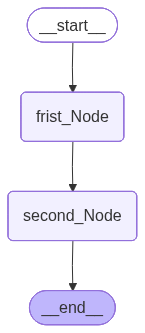

In [15]:
from IPython.display import Image , display

display(app)

In [17]:
app.invoke({"name" : "chita" , "age" : "20"})

{'name': 'chita', 'age': '20', 'final': ' hi chitayou are 20 old'}

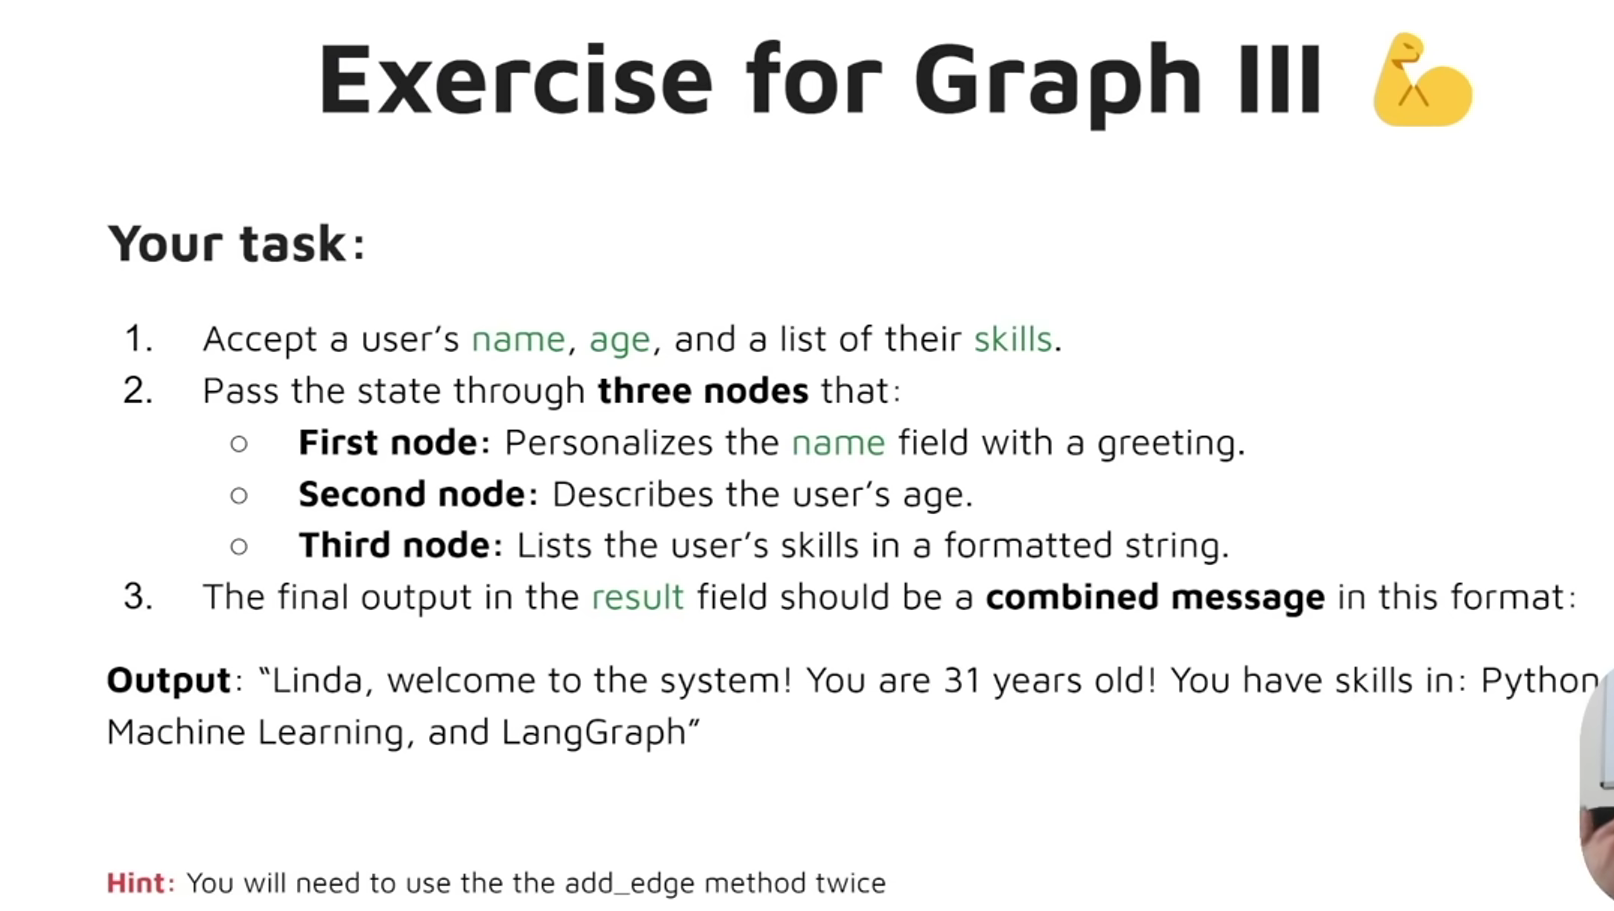

In [26]:
class AgentState1(TypedDict):
    name : str
    age : str
    final : Optional[str]
    skills : str
    

In [29]:
def Personalizer(state : AgentState1) -> AgentState1:
    state["final"] = " welcome to langgraph"

    return state

def Describer(state : AgentState1) -> AgentState1:
    state["final"] = state["final"] + "and your age is " + state["age"]

    return state

def thirdnode(state : AgentState1) -> AgentState1:
    state["final"] = state["final"] + " and these are your skills " + state["skills"]

    return state

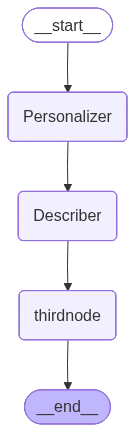

{'name': 'chita',
 'age': '20',
 'final': ' welcome to langgraphand your age is 20 and these are your skills python , java',
 'skills': 'python , java'}

In [30]:
graph1 = StateGraph(AgentState1)

graph1.add_node("Personalizer" , Personalizer)
graph1.add_node("Describer" , Describer)
graph1.add_node("thirdnode" , thirdnode)
graph1.set_entry_point("Personalizer")
graph1.add_edge("Personalizer","Describer")
graph1.add_edge("Describer","thirdnode")
graph1.set_finish_point("thirdnode")

app1 = graph1.compile()
display(app1)
app1.invoke({"name" : "chita" , "age" : "20" , "skills" : "python , java"})